## Random Forest

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np


In [2]:
df = pd.read_csv("data/df_selected.csv")
df_clean = pd.read_csv("data/df_clean.csv")

/tmp/ipykernel_15003/1799877367.py:2: DtypeWarning: Columns (0: CODGEO, 1: Libellé géographique) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("data/df_clean.csv")


In [3]:
y = df_clean["taux_equipement_ve"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42
)

In [5]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [6]:
print("Score train :", rf.score(X_train, y_train))
print("Score test :", rf.score(X_test, y_test))

Score train : 0.3273674738369855
Score test : 0.27574060225020813


Ce qui manque dans tes données :
prix du carburant local
subventions locales
urbanisation fine
disponibilité réelle des bornes
comportement des ménages

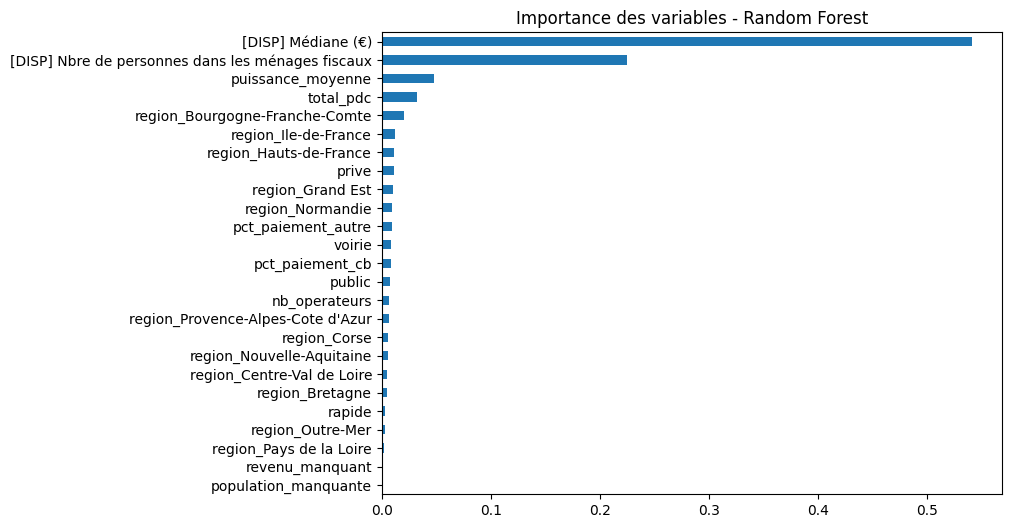

In [7]:
importances = pd.Series(rf.feature_importances_, index=df.columns)
importances = importances.sort_values()

plt.figure(figsize=(8,6))
importances.plot(kind="barh")
plt.title("Importance des variables - Random Forest")
plt.show()

In [8]:
y_pred = rf.predict(X_test)

In [9]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE :", rmse)

RMSE : 0.012749708118340069


L’erreur quadratique moyenne (RMSE) du modèle est d’environ 0,013, ce qui correspond à une erreur moyenne d’environ 1,3 point de pourcentage sur le taux d’équipement en véhicules électriques.
Étant donné que ce taux est en moyenne de l’ordre de 2 %, cette erreur reste significative, traduisant la difficulté à prédire précisément ce phénomène à l’échelle communale.
Toutefois, le modèle permet de capturer les grandes tendances et d’identifier les principaux facteurs explicatifs.

In [10]:
df_result = pd.DataFrame({
    "réel": y_test,
    "prédit": y_pred
})

df_result.head()

,réel,prédit
3635,0.020243,0.018744
12362,0.001898,0.017107
17542,0.025554,0.023738
20881,0.016425,0.025614
441,0.015371,0.020504


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


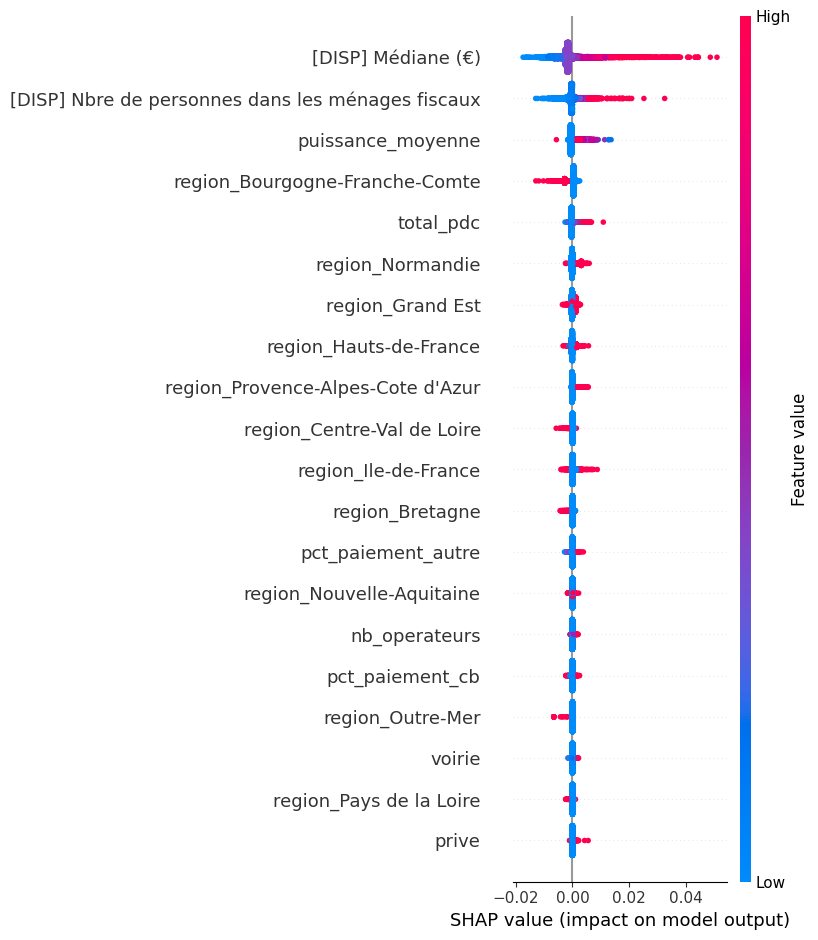

In [11]:
import shap

# explainer
explainer = shap.TreeExplainer(rf)

# calcul des shap values
shap_values = explainer.shap_values(X_test)

# graphique global
shap.summary_plot(shap_values, X_test)